<img src='https://n1s1.hsmedia.ru/df/dc/eb/dfdceb842a1a67240ce7ec2bcb6688d0/1434x1200_1_55d4c5bb657db68504e4e4726eefa7bb@2148x1798_0x43r8yxu9_6443901409871986145.png.webp'>

# Нейронные сети








### Физиологическая модель нейрона

Нейрон (нервная клетка) состоит из:
- тела клетки (cell body),
- внешних ветвей:
    - аксона (axon)
    - дендритов (dendrites).

Тело клетки включает:
- ядро (nucleus), которое содержит информацию о наследственных свойствах,
- плазму, обладающую молекулярными средствами для производства необходимых нейрону материалов.

Нейрон получает сигналы (импульсы) от других нейронов через дендриты (приемники) и передает сигналы, сгенерированные телом клетки, вдоль аксона (передатчик), который в конце разветвляется на волокна (strands). На окончаниях этих волокон находятся синапсы (synapses).

Кора головного мозга человека :
 - поверхностью толщиной от 2 до 3 мм с площадью около 2200 см2.
 - 10^11 нейронов.
 - нейрон связан с 10^3 – 10^4 другими нейронами.
 - мозг человека содержит приблизительно от 10^14 до 10^15 взаимосвязей.


In [1]:
from IPython.display import Image

<img src='https://drive.google.com/uc?export=view&id=1CHbSfdsKulHIFhb93h_cevvb6ApaSNTx'>


## Формальные модели нейрона

In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


### Нейрон МакКалока-Питтса

<img src='https://drive.google.com/uc?export=view&id=1y5ee6Wz6kTMEDpmbc76omk6jXQt2mmmn'>


Построим пример обработки входного х как в нейроне

In [3]:
x = np.array([1,0])
w = np.array([1,-1])

y = np.sign(np.dot(w, x.T )-9.3)
print(y)

-1.0


Посторим нейрон порогового типа

In [4]:
def McCuloh_Pitts_neuron(x = None, w = None, bias = 0):
    # w - веса
    # x - входы
    #print('X: ',x)
    #print('W: ',w)
    #print('bias: ',bias)
    s = np.dot(w, x.T )+ bias
    #print('суммарный уровень входов нейрона на их веса: ',s)
    y = np.sign(s)
    #ind_ = np.where(s>0)[0]
    #y=np.zeros(x.shape[0])
    #y[ind_]=1
    return y

Запустим нейрон на примре х с весами w

In [5]:
x = np.array([1,0])
w = np.array([1,-1])

y_out = McCuloh_Pitts_neuron(x = x, w = w, bias = -0.3)
print('ответ нейрона',y_out)


ответ нейрона 1.0


Подадим много примеров через х и получим много ответов

In [6]:
x = np.random.random((10,2))
w = np.array([1,-1])
y_out1 = McCuloh_Pitts_neuron(x = x, w = w, bias = 0.3)
print('ответ нейрона',y_out1)


ответ нейрона [-1. -1. -1.  1.  1. -1. -1.  1.  1. -1.]


### **Задание 1**
1.1 собрать реализацию модели нейронов с функцией активации:
- линейной
- сигмоидной
- тангенциальной
- сложной сигмоидной 

1.2 построить визуализацию выходов на одинаковом множестве входов

1.3 перечислить достоинства и недостатки активаций

### Линейный нейрон

Линейный нейрон связывает входы в форме y = XW + b

Сделать реализацию функции linear_neuron(x: float = None, w: float = None, bias: float = 0) , где х - входы, w - веса, b - сдвиг

In [76]:
def linear_neuron(x: float = None, w: float = None, bias: float = 0):
    z = np.atleast_2d(x) @ np.asarray(w).reshape(-1,1) + bias   # (n,1)
    return z.T

Запустим нейрон на множестве примеров в х

In [77]:
x = np.random.random((10,2))
w = np.array([1,-1])
y_out1 = linear_neuron(x = x, w = w, bias = 0.3)
print('ответ нейрона',y_out1)

ответ нейрона [[-0.0450182   0.93080061  0.47759778  0.29178646  0.27448363  0.65742902
   0.57968456  0.56300712  0.38102831  0.57936299]]


### Сигмоидный нейрон

Строим сигмоидный нейрон логистический как s = X W + b, y = 1/(1+ exp(-s))


sigmoid_neuron(x: float = None, w: float = None, bias: float = 0)

In [78]:
def sigmoid_neuron(x: float = None, w: float = None, bias: float = 0):
    z = np.atleast_2d(x) @ np.asarray(w).reshape(-1,1) + bias
    y = 1 / (1 + np.exp(-z))
    return y.T

Строим сигмоидный нейрон тангенциальный как s = X W + b, y = 2/(1+ exp(-s))-1

sigmoidt_neuron(x: float = None, w: float = None, bias: float = 0)

In [79]:
def sigmoidt_neuron(x: float = None, w: float = None, bias: float = 0):
    z = np.atleast_2d(x) @ np.asarray(w).reshape(-1,1) + bias
    y = np.tanh(z)
    return y.T

Запустим нейрон

In [80]:
y_out2 = sigmoidt_neuron(x = x, w = w, bias = 0.3)
print('ответ нейрона',y_out2)

ответ нейрона [[-0.04498781  0.73096695  0.44431769  0.28377824  0.26779191  0.57664989
   0.52243613  0.51020518  0.36360016  0.52220228]]


Запустим все нейроны на множестве примеров (линейно равномерно распределены в интервале от -10 до 10)

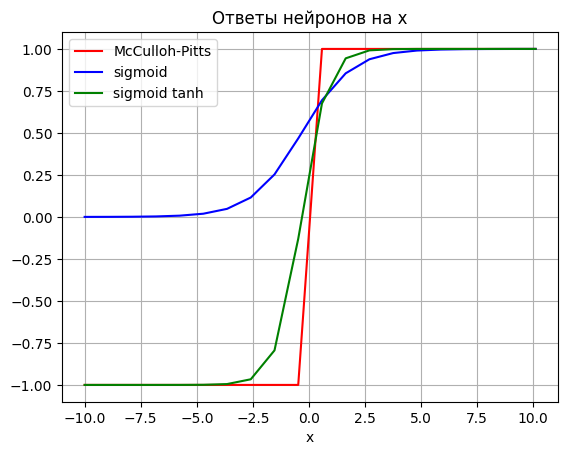

In [82]:
x = np.linspace(-10,10.1,20).reshape((20,1))
w = np.array([0.9]).reshape((1,1))
bias = 0.3

y_out1 = McCuloh_Pitts_neuron(x = x, w = w, bias = 0.3)
y_out2 = sigmoid_neuron(x = x, w = w, bias = 0.3)
y_out3 = sigmoidt_neuron(x = x, w = w, bias = 0.3)
y_out4 = linear_neuron(x = x, w = w, bias = 0.3)

plt.plot(x[:,0].T,y_out1[0,:],'r', label='McCulloh-Pitts')
plt.plot(x[:,0].T,y_out2[0,:],'b', label='sigmoid')
plt.plot(x[:,0].T,y_out3[0,:],'g', label='sigmoid tanh')

plt.legend()
plt.title('Ответы нейронов на х')
plt.xlabel('x')
plt.grid()
plt.show()

Отвеы нейронов для разных нейронов

Пороговый:

In [83]:
y_out1

array([[-1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,  1.,  1.,  1.,
         1.,  1.,  1.,  1.,  1.,  1.,  1.]])

Сигмоидный нейрон:

In [84]:
y_out2

array([[1.66558065e-04, 4.31464081e-04, 1.11722503e-03, 2.88977058e-03,
        7.45358282e-03, 1.90870489e-02, 4.79997991e-02, 1.15549948e-01,
        2.52908880e-01, 4.67283653e-01, 6.94459739e-01, 8.54849947e-01,
        9.38501009e-01, 9.75334342e-01, 9.90334440e-01, 9.96247521e-01,
        9.98548470e-01, 9.99439314e-01, 9.99783541e-01, 9.99916452e-01]])

Сигмоидный тангенциальный нейрон:

In [85]:
y_out3

array([[-0.99999994, -0.99999963, -0.9999975 , -0.9999832 , -0.99988722,
        -0.99924302, -0.99492855, -0.96643608, -0.79436723, -0.13030748,
         0.67564239,  0.9439545 ,  0.99144863,  0.99872171,  0.99980951,
         0.99997163,  0.99999577,  0.99999937,  0.99999991,  0.99999999]])

Усложним сигмоидный нейрон сигмоид с коэффициентом наклона

sigmoidt_complex_neuron(x:float=None, w:float=None, bias:float=0, lymbd:float=1)

In [86]:
def sigmoidt_complex_neuron(x:float=None, w:float=None, bias:float=0, lymbd:float=1):
    z = np.atleast_2d(x) @ np.asarray(w).reshape(-1,1) + bias
    y = np.tanh(lymbd * z)
    return y.T

Посмотрим на работу нейнона

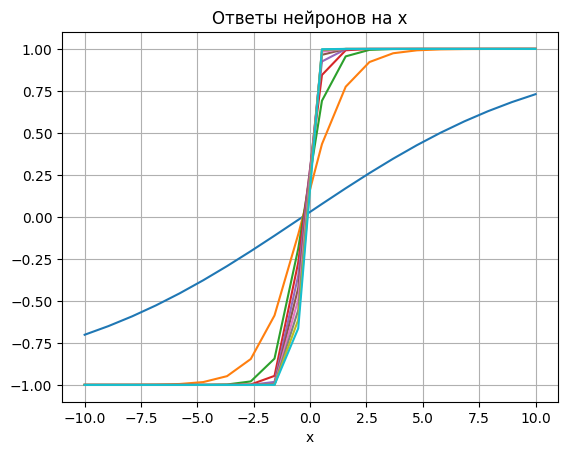

In [87]:
x = np.linspace(-10,10,20).reshape((20,1))
w = np.array([0.9]).reshape((1,1))
bias =0.3

for i in range(10):
    y_out3 = sigmoidt_complex_neuron(x = x, w = w, bias = 0.3, lymbd=0.1+i*0.5)
    plt.plot(x[:,0].T,y_out3[0,:], label='sigmoid tanh')

#plt.legend()
plt.title('Ответы нейронов на х')
plt.xlabel('x')
plt.grid()
plt.show()

### **Задание 2**

2.1. Визуализировать выход 2хмерного нейрона в разных вариантах активаций

**Двухмерный нейрон**

строим поле координат 10х10

In [88]:
x1 = np.array([np.linspace(-10,11,10).reshape((10,1))]*10).reshape((10,10))
x2 = x1.T
x2=x2.reshape((100,1))
x1=x1.reshape((100,1))
print( x1[:3])
print(x2[:3])

x = np.hstack([x1,x2])

[[-10.        ]
 [ -7.66666667]
 [ -5.33333333]]
[[-10.]
 [-10.]
 [-10.]]


Разменость данных

In [89]:
x.shape

(100, 2)

Строим поверхность двухмерного нейрона  (чем желтее, тем ближе к 1, чем синее, тем ближе к -1)

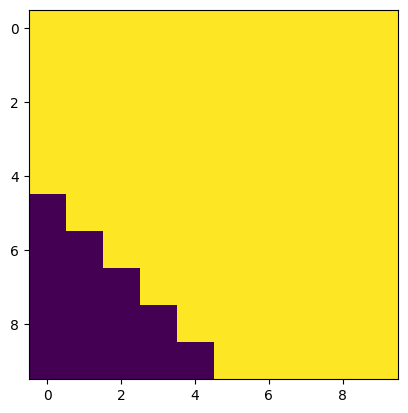

In [90]:
w = np.array([0.9, -0.9]).reshape((1,2))

y_out_21 = McCuloh_Pitts_neuron(x = x, w = w, bias = 10)

y_out_21 = y_out_21.reshape((10,10))

plt.imshow((y_out_21 ))
plt.show()

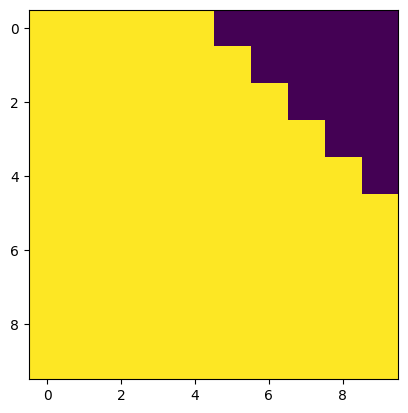

In [91]:
w = np.array([-0.9, 0.9]).reshape((1,2))

y_out_22 = McCuloh_Pitts_neuron(x = x, w = w, bias = 10)

y_out_22 = y_out_22.reshape((10,10))

plt.imshow((y_out_22))
plt.show()

Сигмоидный нейрон на том же пространстве

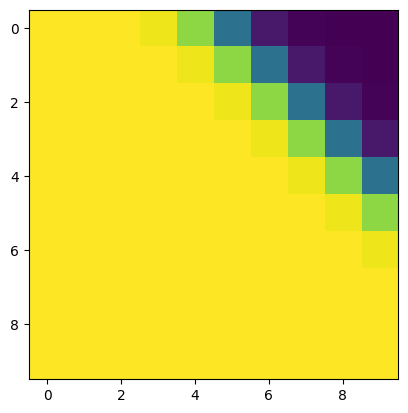

In [92]:
w = np.array([-0.9, 0.9]).reshape((1,2))

y_out_2s = sigmoid_neuron(x = x, w = w, bias = 10)

y_out_2s = y_out_2s.reshape((10,10))

plt.imshow(y_out_2s)
plt.show()

И еще один нейрон

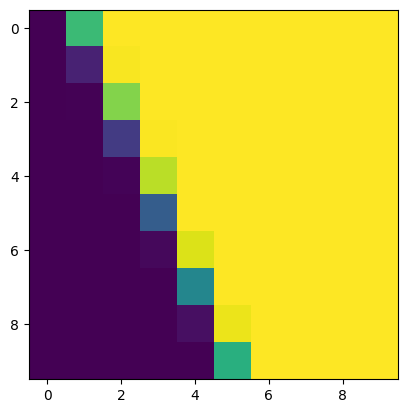

In [93]:
w = np.array([2.9, -1.3]).reshape((1,2))

y_out_21s = sigmoid_neuron(x = x, w = w, bias = 10)

y_out_21s = y_out_21s.reshape((10,10))

plt.imshow(y_out_21s)
plt.show()

И еще один нейрон

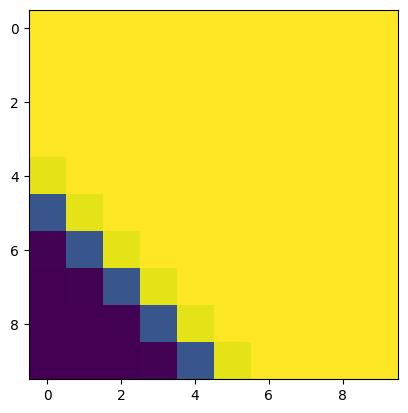

In [94]:
w = np.array([0.9, -0.9]).reshape((1,2))

y_out_22s = sigmoidt_neuron(x = x, w = w, bias = 10)

y_out_22s = y_out_22s.reshape((10,10))
plt.imshow(y_out_22s)
plt.show()

Все нейроны отличаются весами, что приводит к разным выходам.

### **Задание 3**

3.1. Сделать реализацию обучения по Дельта-правилу(правило Вудро-Хофа) для линейного нейрона

3.2. Сделать реализацию обучения по Дельта-правилу для сигмоидного нейрона

3.3. визуализировать результат обучения для набора данных : 

**# входное пространство**

x1 = np.array([1,1,-1,-1])
x2 = np.array([1,-1,-1,1])

x = np.vstack([x1,x2]).T

**# целевые значения для входов**

D=np.array([1,1,-1,-1])

**Обучение линейного нейрона**

1. Задать начальное состояние
2. Взять пример j из набора примеров
3. Вычислить выход нейрона для этого примера
4. Вычислить коррекцию синаптических весов для всех входов xi

dwi = - n (y(Хj) - dj) xi

5. Вычислить новый уровень wi
wi = wi +  dwi

6. Перейти к новому примеру в п.2
7. Если просмотрели все примеры, то проверить условие конца (ошибка модели или число повторов):
    - условие выполнено - конец
    - условие не выполнено - начинаем просматривать примеры и изменять веса сначала (j=0) и к п.2
    


Эпоха - просмотр всех примеров из набора

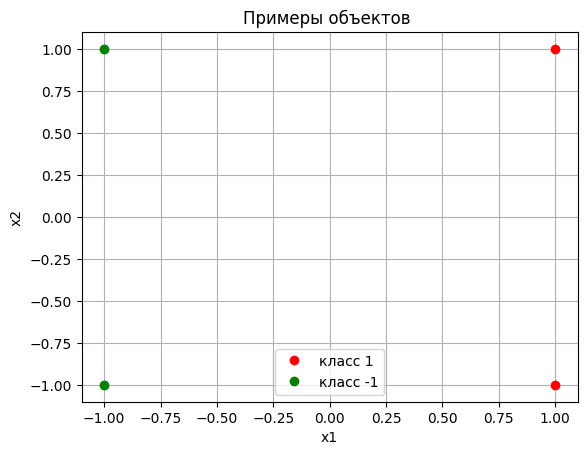

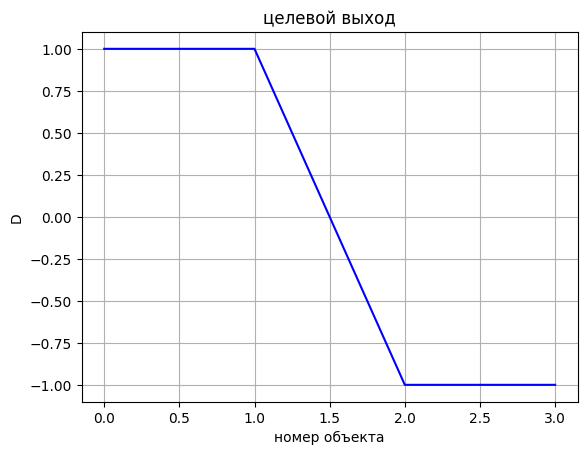

In [96]:
# входное пространство
x1 = np.array([1,1,-1,-1])
x2 = np.array([1,-1,-1,1])

x = np.vstack([x1,x2]).T

# целевые значения для входов
D=np.array([1,1,-1,-1])
# нарисуем
plt.plot(x1[:2],x2[:2], 'or', label = 'класс 1')
plt.plot(x1[2:4],x2[2:4], 'og', label = 'класс -1')
plt.legend()
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Примеры объектов ')
plt.grid()
plt.show()

plt.plot(D, 'b')
plt.title('Примеры значений класса ')
plt.title('целевой выход')
plt.xlabel('номер объекта')
plt.ylabel('D')
plt.grid()
plt.show()

Посмотрим на входы

In [97]:
x

array([[ 1,  1],
       [ 1, -1],
       [-1, -1],
       [-1,  1]])

Научим нейрон понимать эти примеры

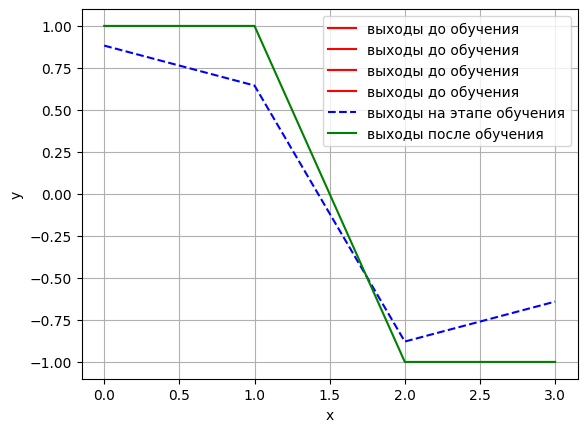

In [107]:
# Начальные веса
w=np.array([0.1,0.2])

#yt = sigmoid_neuron(x = x, w = w, bias = 0)
yt = linear_neuron(x = x, w = w, bias = 0)
plt.plot(yt,'r' , label = 'выходы до обучения')


## реализовать обучение нейрона
eta = 0.2
epochs = 15
b = 0.0

history = []

for ep in range(epochs):
    for j in range(x.shape[0]):
        xj = x[j]
        yj = float(np.dot(w, xj) + b)        # для сигмоиды: float(sigmoid_neuron(xj, w, b))
        dj = float(D[0, j] if D.ndim == 2 else D[j])
        err = yj - dj
        w = w - eta * err * xj
        b = b - eta * err
    y_epoch = (x @ w.reshape(-1,1) + b).T    # для сигмоиды: sigmoid_neuron(x, w, b)
    history.append(y_epoch)

plt.plot(yt,'--b', label = 'выходы на этапе обучения')
plt.plot(yt,'g', label = 'выходы после обучения')
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.grid()
plt.show()

**Обучение линейного нейрона**

1. Задать начальное состояние
2. Взять пример j из набора примеров
3. Вычислить выход нейрона для этого примера
4. Вычислить коррекцию синаптических весов для всех входов xi

dwi = - n (y(Хj) - dj) xi

5. Вычислить новый уровень wi
wi = wi +  dwi

6. Перейти к новому примеру в п.2
7. Если просмотрели все примеры, то проверить условие конца (ошибка модели или число повторов):
    - условие выполнено - конец
    - условие не выполнено - начинаем просматривать примеры и изменять веса сначала (j=0) и к п.2
    


Эпоха - просмотр всех примеров из набора

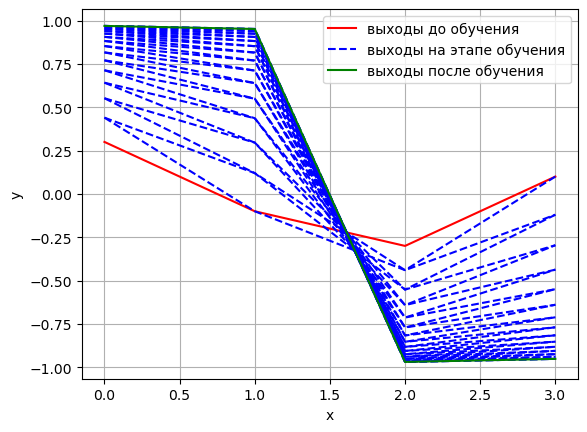

In [90]:
# Начальные веса
w=np.array([0.1,0.2])

#yt = sigmoid_neuron(x = x, w = w, bias = 0)
yt = sigmoid_neuron(x = x, w = w, bias = 0)
plt.plot(yt,'r' , label = 'выходы до обучения')


plt.plot(yt,'--b', label = 'выходы на этапе обучения')
plt.plot(yt,'g', label = 'выходы после обучения')
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.grid()
plt.show()

На графике видно, как изменяется выход нейрона при обучении (постепенно сдвигаем к целевому значению)

### **Задание 4**

4.1. визуализировать результат обучения для набора данных : 

**# входное пространство**

x1 = np.array([1,1,-1,-1])
x2 = np.array([1,-1,-1,1])

x = np.vstack([x1,x2]).T

**# целевые значения для входов**

D=np.array([1,-1,1,-1])

**Линейная разделимость**

Введем понятие разделимость :
- линейная - можно поделить линейной границей
- линейно не разделимая - нельзя провести линейную границу

<img src='https://drive.google.com/uc?export=view&id=1jysvUhdc4EvJHhTbliZGFq8fRl9-L1Ek'>


Приведем пример линейно не разделимой модели примеров

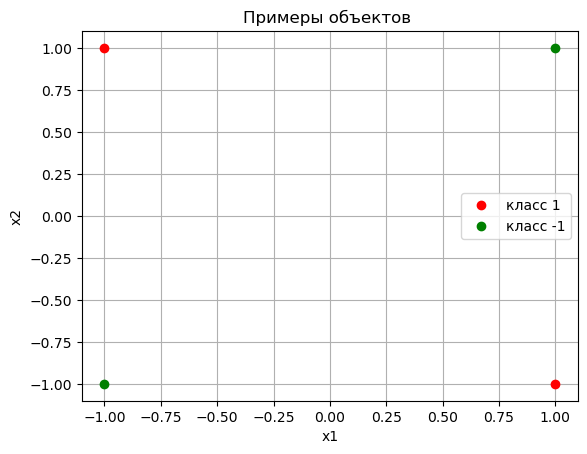

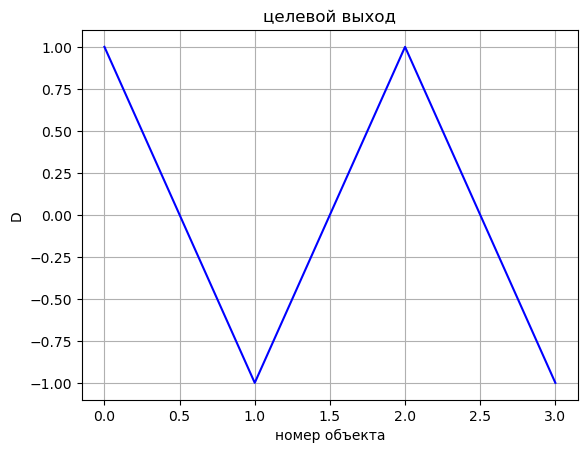

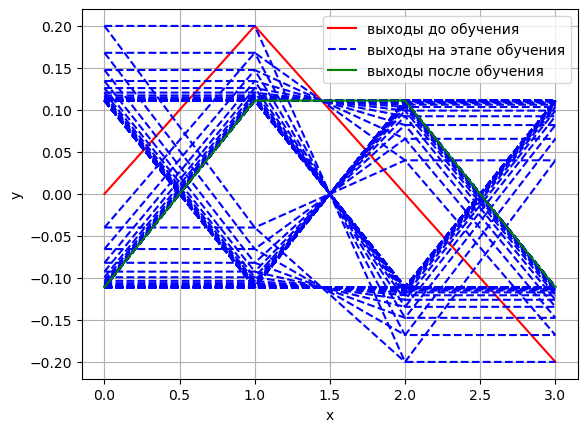

In [91]:
# зададим примеры на вход
x1 = np.array([1,1,-1,-1])
x2 = np.array([1,-1,-1,1])

x = np.vstack([x1,x2]).T
# зададим примеры на выход
D=np.array([1,-1,1,-1])

plt.plot(x1[[1,3]],x2[[1,3]], 'or', label = 'класс 1')
plt.plot(x1[[0,2]],x2[[0,2]],'og', label = 'класс -1')
plt.legend()
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Примеры объектов ')
plt.grid()
plt.show()

plt.plot(D, 'b')
plt.title('Примеры значений класса ')
plt.title('целевой выход')
plt.xlabel('номер объекта')
plt.ylabel('D')
plt.grid()
plt.show()

# Начальные веса
w=np.array([0.1,-0.1])

#yt = sigmoid_neuron(x = x, w = w, bias = 0)
yt = linear_neuron(x = x, w = w, bias = 0)


plt.plot(yt,'r' , label = 'выходы до обучения')

# попробуем обучить
# Ваш код обучения


plt.plot(yt,'--b', label = 'выходы на этапе обучения')
plt.plot(yt,'g', label = 'выходы после обучения')
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.grid()
plt.show()

Посмотрели на результаты и видим, что обучения не произошло и веса бросает туда-сюда:(. Нейрон не обучается (2 ошибки на 4 примера)

### **Задание 5**

5.1. Сделать комбинацию выходов нейронов (сигмоидных) с весами

5.2. визуализировать результат работы в двухмерном пространстве входов.

Можно строить сколько угодно сложные модели если :
- нейрон может это реализовать
- нейрон можно этому обучить

**Проверим, что можно построить из комбинаций нейронов:**

Скомбинируем нейроны y_out_21 и y_out_22

## комплекс нейронов

Объединим ответы 2-х нейронов в третьем (выходы 2-х первых - входы третьего)

In [92]:
x_y2=np.hstack([y_out_21.reshape((100,1)),y_out_22.reshape((100,1))])
x_y2.shape

(100, 2)

Запустим нейрон и оказывается , что он может объединить решения неронов , т.е. 1 выставляем только там, где оба входных нейрона выставили 1. Остальные области помечены 0.

Покажем это на схеме

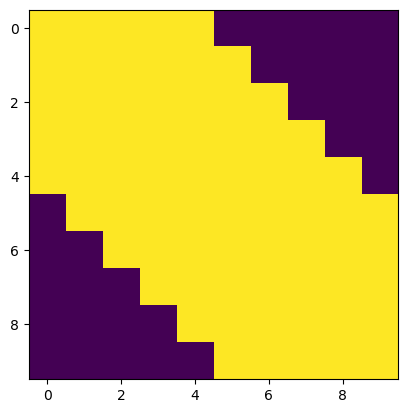

In [93]:
yy2 = McCuloh_Pitts_neuron(x = x_y2, w = np.array([1,1]), bias = -0.5)
yy2=yy2.reshape((10,10))

plt.imshow((yy2 ))
plt.show()

Построим еще одно объединение  - "Уголком"

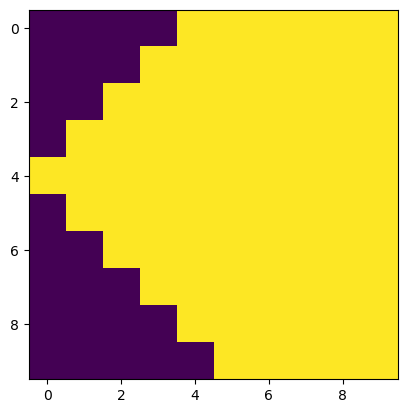

In [94]:
x1 = np.array([np.linspace(-10,11,10).reshape((10,1))]*10).reshape((10,10))
x2 = x1.T
x2=x2.reshape((100,1))
x1=x1.reshape((100,1))

x = np.hstack([x1,x2])

#neuron 1
w = np.array([0.9, -0.9]).reshape((1,2))

y_out_31 = McCuloh_Pitts_neuron(x = x, w = w, bias = 10)
#neuron 2
w = np.array([0.9, 0.9]).reshape((1,2))

y_out_32 = McCuloh_Pitts_neuron(x = x, w = w, bias = 10)

#второй слой - нейрон 1
x_y3=np.hstack([y_out_31.reshape((100,1)),y_out_32.reshape((100,1))])
x_y3.shape

yy3 = McCuloh_Pitts_neuron(x = x_y3, w = np.array([1,1]), bias = -0.5)
yy3=yy3.reshape((10,10))

plt.imshow((yy3 ))
plt.show()

Схема нейронной модели из 3-х нейронов ;

<img src='3_neurons.png'>


Это уже нейронная сеть!!!!

### Нейронная сеть

Слой - группа нейронов :
    - близкие функции
    - связаны с общим подмножеством нейронов
    
Слой на выходе - выходной

Слой на входе - рецептивный

**Формальная модель сети**


<img src='neuronet.png'>


Возможности сети:

- 2-х слойная сеть {0,1}n - произвольная булева функция (ДНФ)
- 2-х слойная сеть Rn - произвольный выпуклый многогранник
- 3-х слойная сеть Rn - произвольная не обязательно выпуклая область , не обязательно связная
- линейные операции + одна нелинейная - приблизит любу. непрерывную функцию с любой точностью

Пример 2-х слойная сеть Rn - произвольный выпуклый многогранник

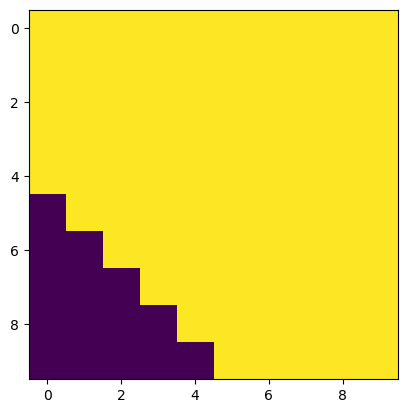

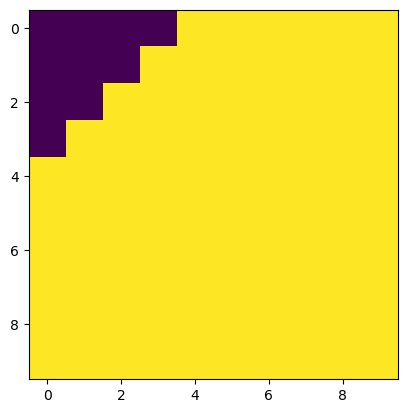

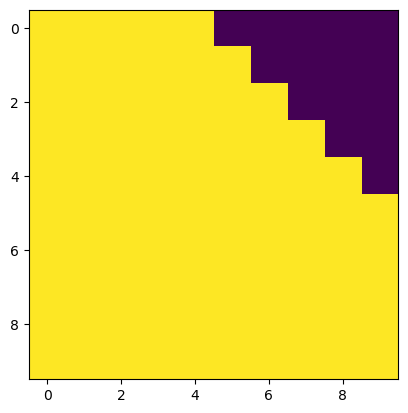

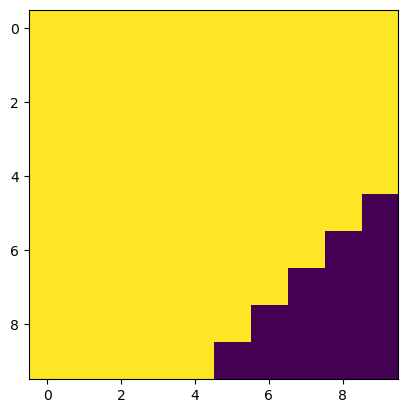

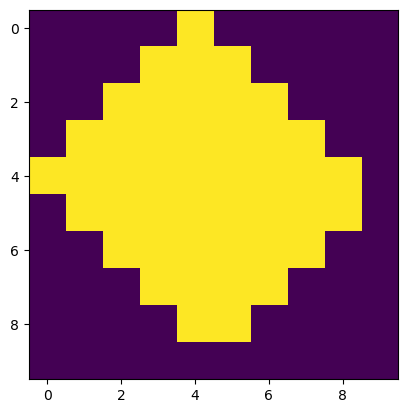

In [95]:
x1 = np.array([np.linspace(-10,11,10).reshape((10,1))]*10).reshape((10,10))
x2 = x1.T
x2=x2.reshape((100,1))
x1=x1.reshape((100,1))

x = np.hstack([x1,x2])

#neuron 1
w = np.array([0.9, -0.9]).reshape((1,2))

y_out_31 = McCuloh_Pitts_neuron(x = x, w = w, bias = 10)
plt.imshow((y_out_31.reshape((10,10)) ))
plt.show()
#neuron 2
w = np.array([0.9, 0.9]).reshape((1,2))

y_out_32 = McCuloh_Pitts_neuron(x = x, w = w, bias = 10)
plt.imshow((y_out_32.reshape((10,10)) ))
plt.show()
#neuron 3
w = np.array([-0.9, 0.9]).reshape((1,2))

y_out_33 = McCuloh_Pitts_neuron(x = x, w = w, bias = 10)
plt.imshow((y_out_33.reshape((10,10)) ))
plt.show()
#neuron 4
w = np.array([-0.9, -0.9]).reshape((1,2))

y_out_34 = McCuloh_Pitts_neuron(x = x, w = w, bias = 10)
plt.imshow((y_out_34.reshape((10,10)) ))
plt.show()


#второй слой - нейрон 1
x_y3=np.hstack([y_out_31.reshape((100,1)),y_out_32.reshape((100,1)), y_out_33.reshape((100,1)), y_out_34.reshape((100,1))])
x_y3.shape

#выходной нейрон - собирает сигнал 4-х нейронов и описывает общую фигуру , т.е. комбинируем 4 линейных границы
yy3 = McCuloh_Pitts_neuron(x = x_y3, w = np.array([0.25,0.25,0.25,0.25]), bias = -0.5)
#yy3 = linear_neuron(x = x_y3, w = np.array([0.24,0.24,0.24,0.24]), bias = 0)
yy3=yy3.reshape((10,10))

plt.imshow((yy3 ))
plt.show()

In [96]:
yy3

array([[0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 1., 1., 0., 0., 0., 0.],
       [0., 0., 1., 1., 1., 1., 1., 0., 0., 0.],
       [0., 1., 1., 1., 1., 1., 1., 1., 0., 0.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 0.],
       [0., 1., 1., 1., 1., 1., 1., 1., 1., 0.],
       [0., 0., 1., 1., 1., 1., 1., 1., 0., 0.],
       [0., 0., 0., 1., 1., 1., 1., 0., 0., 0.],
       [0., 0., 0., 0., 1., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

<img src='https://drive.google.com/uc?export=view&id=1WHFe1TqyDG2bVJKOoNL2YWOFMPbuuTxt'>


3-х слойная сеть Rn - произвольная не обязательно выпуклая область

In [97]:
# Image(filename='8.png', width=600)

<img src='8.png'>

<img src='https://drive.google.com/uc?export=view&id=1FWpEBzvk2WQW99tAuASlaHO3tu09wnaf'>


## Резюме

1. Нейрон - биологическое подобие
2. Нейрон - обучаем
3. Нейрон - простая функция
4. Нейронная сеть - сложная функция
5. Нейронная сеть - обучаема